# 01 Data Audit

Inspect raw annotation files, class balance, duplicates, and sentiment-bearing symbols before training.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_utils import build_paths, discover_raw_files, merge_annotation_files, build_label_audit

paths = build_paths()
raw_files = discover_raw_files(paths.raw_dir)
raw_files

[WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2/data/raw/annotator_1_data.csv'),
 WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2/data/raw/annotator_2_data.csv'),
 WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2/data/raw/annotator_3_data.csv'),
 WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2/data/raw/annotator_4_data.csv'),
 WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2/data/raw/annotator_5_data.csv'),
 WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2/data/raw/annotator_6_data.csv'),
 WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/Prototyping 2/data/raw/Copy of Facebook_Comment_Annotation - Perpetual.csv'),
 WindowsPath('C:/Users/vdchi/OneDrive/Documents/DATA SCIENCE/Sem5/Group Project/

In [2]:
merged = merge_annotation_files(raw_files)
audit = build_label_audit(merged)
merged.head()

Skipping annotator_1_data.csv: annotator_1_data.csv is missing required columns: include, sentiment_label
Skipping annotator_2_data.csv: annotator_2_data.csv is missing required columns: include, sentiment_label
Skipping annotator_3_data.csv: annotator_3_data.csv is missing required columns: include, sentiment_label
Skipping annotator_4_data.csv: annotator_4_data.csv is missing required columns: include, sentiment_label
Skipping annotator_5_data.csv: annotator_5_data.csv is missing required columns: include, sentiment_label
Skipping annotator_6_data.csv: annotator_6_data.csv is missing required columns: include, sentiment_label
Skipped 6 raw files without the required annotation schema.


,id,text,topic_label,sentiment_label,confidence,include,notes,source_file
0,330.0,Good movie,Economy,Positive,Low,No,no topic,Copy of Facebook_Comment_Annotation - Perpetua...
1,331.0,Salute,Economy,Positive,Low,No,too short,Copy of Facebook_Comment_Annotation - Perpetua...
2,332.0,Zamphamvu kwambiri,Economy,positive,Medium,Yes,praise,Copy of Facebook_Comment_Annotation - Perpetua...
3,333.0,The machine,Economy,Neutral,Low,No,unclear,Copy of Facebook_Comment_Annotation - Perpetua...
4,334.0,"Learning by doing approach, that's wonderful 🔥 🔥.",Economy,positive,High,Yes,teaching method,Copy of Facebook_Comment_Annotation - Perpetua...


In [15]:
audit.columns

Index(['id', 'text', 'topic_label', 'sentiment_label', 'confidence', 'include',
       'notes', 'source_file', 'sentiment_label_normalized',
       'include_normalized', 'text_missing', 'text_length_chars',
       'token_count_whitespace', 'is_short_comment', 'is_duplicate_text',
       'exclude_reason'],
      dtype='object')

In [19]:
merged[merged["text"] == "Mbambande 🔥"]

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file
13,98,Mbambande 🔥,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv
73,161,Mbambande 🔥,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv
336,184,Mbambande 🔥,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Thando.csv
346,195,Mbambande 🔥,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Thando.csv


In [4]:
audit[['source_file', 'sentiment_label', 'sentiment_label_normalized', 'include', 'exclude_reason']].head(10)

,source_file,sentiment_label,sentiment_label_normalized,include,exclude_reason
0,Facebook_Comment_Annotation - Alfred.csv,Negative,negative,Yes,
1,Facebook_Comment_Annotation - Alfred.csv,Neutral,neutral,Yes,
2,Facebook_Comment_Annotation - Alfred.csv,Negative,negative,Yes,
3,Facebook_Comment_Annotation - Alfred.csv,Positive,positive,Yes,
4,Facebook_Comment_Annotation - Alfred.csv,Positive,positive,Yes,
5,Facebook_Comment_Annotation - Alfred.csv,Positive,positive,Yes,
6,Facebook_Comment_Annotation - Alfred.csv,Neutral,neutral,Yes,
7,Facebook_Comment_Annotation - Alfred.csv,Negative,negative,Yes,
8,Facebook_Comment_Annotation - Alfred.csv,Positive,positive,Yes,
9,Facebook_Comment_Annotation - Alfred.csv,Positive,positive,Yes,


In [5]:
audit['sentiment_label_normalized'].value_counts(dropna=False)

sentiment_label_normalized
positive    340
neutral      98
negative     39
None          3
Name: count, dtype: int64

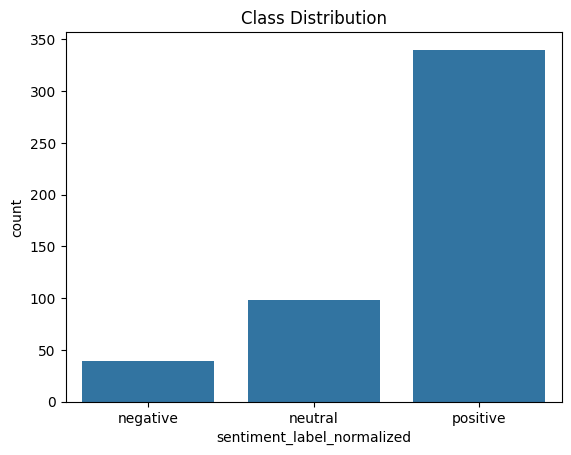

In [20]:
sns.countplot(data=audit, x='sentiment_label_normalized', order=['negative', 'neutral', 'positive'])
plt.title('Class Distribution')
plt.show()

In [21]:
audit['text_length_chars'].describe()

count    480.000000
mean      49.416667
std       70.355861
min        4.000000
25%       16.000000
50%       25.000000
75%       50.000000
max      666.000000
Name: text_length_chars, dtype: float64

In [22]:
emoji_counts = merged['text'].fillna('').str.count(r'[\U00010000-\U0010ffff]')
emoji_counts.describe()

count    480.000000
mean       0.693750
std        1.375282
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       14.000000
Name: text, dtype: float64

In [23]:
audit[audit['exclude_reason'] != ''][['text', 'exclude_reason', 'source_file']].head(20)

,text,exclude_reason,source_file
66,Malawi got talent indeed imagine set up fire u...,include_not_yes,Facebook_Comment_Annotation - Alfred.csv
73,Mbambande 🔥,duplicate_text,Facebook_Comment_Annotation - Alfred.csv
84,Dowa nd dziko palokha,include_not_yes,Facebook_Comment_Annotation - Fitina.csv
87,Ndiye wina kugula ma galimoto 84 onse for luxu...,include_not_yes,Facebook_Comment_Annotation - Fitina.csv
92,Sukulu kuchedwetsa abale 🙌🙌🙌,include_not_yes,Facebook_Comment_Annotation - Fitina.csv
96,Good development,duplicate_text,Facebook_Comment_Annotation - Fitina.csv
101,Mphwache wa Dangote uyu...🤣🤣🤣🤣,include_not_yes,Facebook_Comment_Annotation - Fitina.csv
102,Dowa ija si Malawi osazaitola anthu ake ndioga...,include_not_yes,Facebook_Comment_Annotation - Fitina.csv
106,Dzombe is a country on his own 🔥🔥🔥🔥🔥,include_not_yes,Facebook_Comment_Annotation - Fitina.csv
107,Apa ndikutha kuopa NAPOLEON akubwera pa one th...,include_not_yes,Facebook_Comment_Annotation - Fitina.csv
